In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn_Model import Accumulation_Site

In [2]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

def cum_mat_prod(A,N):
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

In [3]:
def interp_mat(out, grid_in): # interpolates from grid_in to out
    # input arrays must have broadcastable shape
    # grid's primary index should be along axis -1
    slope = ((out[...,:-1 if out.shape[-1]>1 else None]-grid_in[...,:-1])/np.diff(grid_in,axis=-1)).clip(0,1) # slope from 0 to 1 as x passes from lower to upper bound
    return np.concatenate(
        [1*(out[...,:1]>=grid_in[...,:1])-slope[...,:1],
         -np.diff(slope, axis=-1),
         slope[...,-1:]-1*(out[...,-1:]>grid_in[...,-1:])],
        axis=-1)

# Setup

## Load Matlab Run

In [4]:
runMat = scipy.io.loadmat('matlab/Firn Ice Model/Firn Model - CIC Forward Model v5.0/Runs/Run2026-07-21_08h59m.mat')
runMat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Jul 21 09:00:16 2026',
 '__version__': '1.0',
 '__globals__': [],
 'Acc': array([[0.032]]),
 'None': MatlabOpaque([(b'An2', b'MCOS', b'matlab.graphics.shape.TextBox', array([[3707764736],
                      [         2],
                      [         1],
                      [         1],
                      [         1],
                      [         2]], dtype=uint32))                                    ],
              dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]),
 'ApplyUncert': array([[0]], dtype=uint8),
 'Apply_14CO_adj': array([[0]], dtype=uint8),
 'C14CH4_color': array([[0, 1, 0]], dtype=uint8),
 'C14CO2_color': array([[0.2 , 0.73, 1.  ]]),
 'C14CO_color': array([[0.8, 0.8, 0. ]]),
 'C14CO_const': array([[12]], dtype=uint8),
 'C14CO_const_u': array([[2]], dtype=uint8),
 'C14CO_hist': array(['constant'], dtype='<U8'),
 'C14CO_hist_dX_lin': array([[-0.6]]),
 'C14CO_hist_dX_pct': arr

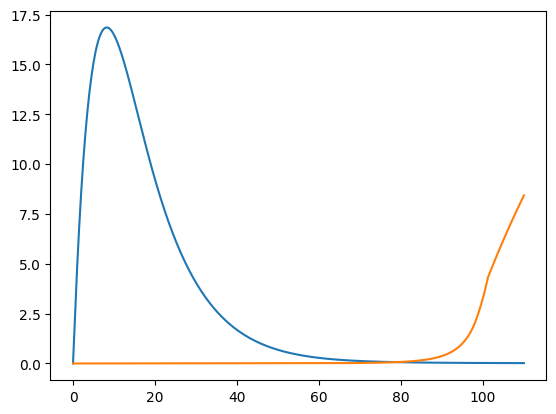

In [5]:
plt.plot(runMat['z'], runMat['C14_grains'][:,-1,1])
plt.plot(runMat['z'], runMat['C14_closed'][:,-1,1])

## Set Parameters

In [6]:
#COS_partition = np.array(
#    [#CO2         CO          CH4
#    [0.686307104, 0.31125305, 0.002439846], # neutron
#    [0.686307104, 0.31125305, 0.002439846], # neg muon
#    [0.686307104, 0.31125305, 0.002439846], # fast muon
#])
COS_partition = runMat['COS_partition']

#L = np.array([1, 7e-4])
L = np.array([1,runMat['leakage'][0,0]['closed'][0,1]])
Res = runMat['Res_partition'][0]

#f_factors = np.array([1., 0.06, 0.08])
#P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]]) * COS_partition[0,1]
P0_tuning = runMat['P0_tuning'][0] * COS_partition[0,1]
f_factors = P0_tuning * np.array([1/COS_partition[0,1], 1, 1])
f_factors

array([1.03 , 0.065, 0.07 ])

In [7]:
runMat['leakage'][0,0]['closed'][0]

array([1.    , 0.0045, 0.001 ])

## Load Propagator Model

In [8]:
Prop_DC = Propagator()

## Load Firn Model

In [9]:
#Dome_C = Accumulation_Site(t_resol=10)
Dome_C = Accumulation_Site(z_end=runMat['z_end'][0,0],
                           t_end=runMat['t_end'][0,0],
                           #t_resol=10,
                           C14CO_const=int(runMat['C14CO_const'][0,0]),
                           Acc=runMat['Acc'][0,0],
                          )

# caculate cosmogenic 14C in reservoirs w/ Leakage rates L
t = time()
C14_grains, C14_leak_open, C14_leak_closed, C14_cumuleak_closed = Dome_C.Calc_14C_ice(L=L)
print(time()-t)

# calculate 14CO concentrations in open porosity, + concentration trapped into closed porosity
C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Dome_C.Calc_profiles(C14_leak_open, analytic=True)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:219: RuntimeWarning: invalid value encountered in divide
  bubble_pres = np.sum((dscl * C * self.s)[None,:] * self.dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(self.s*(self.s_closed-self.s_closed[0]))
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:359: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:361: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(lambd+Lrate)*(COS_age+COS_dt)) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:597: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)


0.008559465408325195
0.010754823684692383
interpolating...


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 84.49it/s]


integrating...
  Calculated open and closed profiles for gas 1 out of 1
0.22753381729125977


## Load Samples

In [10]:
pd_DomeC = pd.read_excel('DomeC 14CO data analysis current.xlsx', '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])
pd_DomeC

,"Mean depth, m","14CO, molec / g ice after all corrections","Error, 1 sigma","Mean gas age, yr before 1950","Mean gas age, Years before measurement date"
Sample,,,,,
14CO_UR_DC_FIRN_SAMPLE_1,34.000,46.438967,1.143309,NaN,NaN
14CO_UR_DC_FIRN_SAMPLE_2,54.500,28.289650,0.749249,NaN,NaN
14CO_UR_DC_FIRN_EXTRACTION_3,75.000,18.807095,0.543124,NaN,NaN
14CO_UR_DC_ICE_SAMPLE_1,110.000,18.669397,0.885088,434.483581,510.483581
14CO_UR_DC_ICE_SAMPLE_3,150.000,26.848805,0.679599,1901.485970,1977.485970
14CO_UR_DC_ICE_SAMPLE_4,170.000,28.480674,0.573240,2717.573599,2793.573599
14CO_UR_DC_ICE_SAMPLE_5,190.500,29.289987,0.601586,3323.027758,3399.027758
14CO_UR_DC_ICE_SAMPLE_6,211.000,29.666008,0.722400,4118.909061,4194.909061
14CO_UR_DC_ICE_SAMPLE_7,230.925,28.951245,0.655983,4761.798084,4837.798084


In [11]:
z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
# separate samples into categories
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

## Setup Grids

In [24]:
New = False

In [25]:
if New:
    lambd = Prop_DC.lambd
else:
    lambd = Dome_C.decay_gas['C14_CO']
lambd

0.00012096286440062901

(441,)


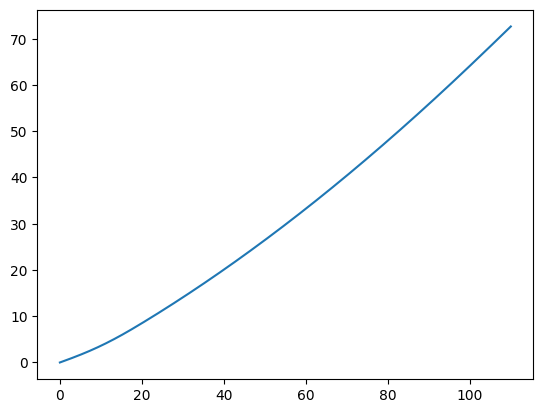

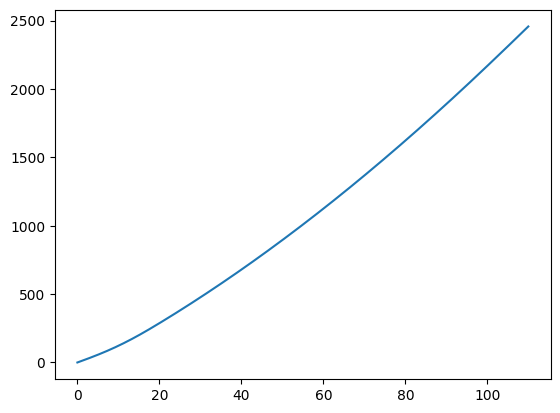

In [26]:
# age & depth interpolation grids [grid]
# equally space in age
if New:
    z_grid = Prop_DC.z_grid
    h_grid = Prop_DC.h_grid
    age_grid = Prop_DC.age_grid
else:
    z_grid = Dome_C.z
    h_grid = Dome_C.IceAge * Dome_C.Acc * Dome_C.rho_ice
    age_grid = Dome_C.IceAge
print(z_grid.shape)

plt.plot(z_grid, h_grid)
plt.show()

plt.plot(z_grid, age_grid)
plt.show()

In [27]:
# Production times [bins]
dt1 = 1
#dt1 = Dome_C.t_resol
#t_end = 10000
t_end = runMat['t_end'][0,0]
t1_bins = np.arange(0, t_end+dt1, dt1)
t1_bins = t1_bins-t1_bins[-1]
if New:
    t1 = (t1_bins[:-1]+t1_bins[1:])/2
else:
    t1 = t1_bins
t1.shape

(3001,)

In [28]:
age1_bins = t1_bins-t1_bins[0]
age1 = (age1_bins[:-1]+age1_bins[1:])/2
dage1 = np.diff(age1_bins)

z1_bins = np.interp(age1_bins, age_grid, z_grid)
z1 = (z1_bins[:-1]+z1_bins[1:])/2
dz1 = np.diff(z1_bins)

h1_bins = np.interp(age1_bins, age_grid, h_grid)
h1 = (h1_bins[:-1]+h1_bins[1:])/2
dh1 = np.diff(h1_bins)
age1.shape

(3000,)

In [29]:
# Accumulation time resolution
dt_A = Dome_C.t_resol
dt_A

0.5

In [30]:
# Diffusion time resolution
dt_D = Dome_C.dt
dt_D

0.01

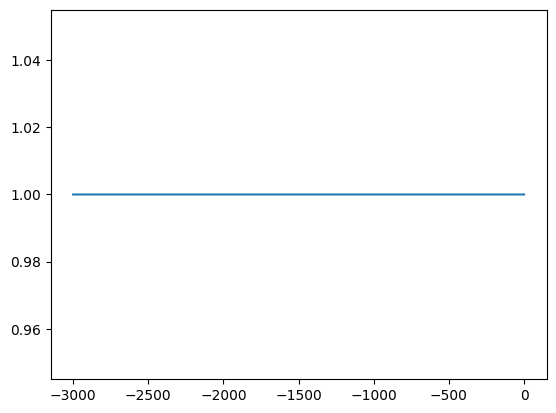

In [31]:
# GCR Flux History
phi = np.ones(len(t1))
plt.plot(t1, phi)

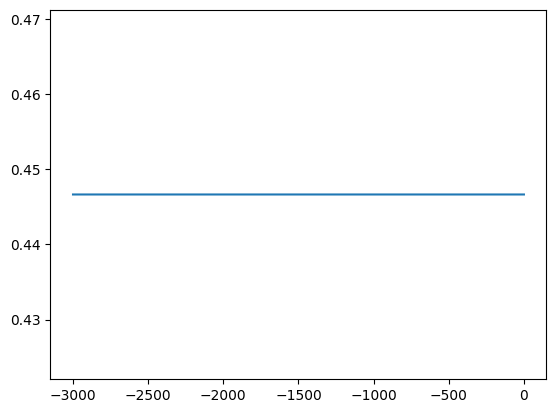

In [32]:
# Atmospheric 14CO history
gas_history = Dome_C.gas_history['C14_CO'][0]*np.ones(len(t1))
plt.plot(t1, gas_history)

In [33]:
# Production Depths [grid]
# equally space in age
if New:
    p = Prop_DC.h_bins
else:
    Site = Dome_C
    p_dt = dt1
    p_t = np.arange(-Site.t_end, 1e-10, p_dt)

    #ice-eqiv depth
    dp = Site.Acc * p_dt
    p = np.arange(dp/2, Site.dz * np.sum(Site.rho)/Site.rho_ice + 2 * Site.dz, dp) * Site.rho_ice # depth bin centers
    dp *= Site.rho_ice

    # interpolate COS_z to real depth, integrating “dummy” density to get mass depth ranges
    p_z = np.interp(p, scipy.integrate.cumulative_trapezoid([*Site.rho, Site.rho_ice], x=[*Site.z, Site.z[-1]+30], initial=0), [*Site.z, Site.z[-1]+30])

    # Run the calculation
    p_age = np.arange(len(p_z))*p_dt+p_dt/2 # age of ice at ice-eq depth COS_z
    #dp_age = dt1
    #p_age = np.arange(0, age_grid[-1]+1e-10, dp_age)
    #p = np.interp(p_age, age_grid, h_grid)
    #p_z = np.interp(p_age, age_grid, z_grid)
p.shape

/tmp/ipykernel_1778/1206660009.py:8: RuntimeWarning: overflow encountered in scalar negative
  p_t = np.arange(-Site.t_end, 1e-10, p_dt)


(2478,)

In [34]:
# Accumulation Bins [bins]
# equally spaced in time / ice age
# used to track ice parcels as 14CO accumulates
if New:
    dt_acc = 0.5 #yrs
else:
    dt_acc = Dome_C.t_resol
t_acc_bins = np.arange(0, t_end+1e-10, dt_acc)
t_acc_bins = t_acc_bins - t_acc_bins[-1]
t_acc = (t_acc_bins[:-1]+t_acc_bins[1:])/2

age_acc_bins = np.arange(0,age_grid[-1]+dt_acc,dt_acc)
age_acc = (age_acc_bins[:-1]+age_acc_bins[1:])/2
dage_acc = np.diff(age_acc_bins)

z_acc_bins = np.interp(age_acc_bins, age_grid, z_grid)
z_acc = (z_acc_bins[:-1]+z_acc_bins[1:])/2
dz_acc = np.diff(z_acc_bins)

h_acc_bins = np.interp(age_acc_bins, age_grid, h_grid)
h_acc = (h_acc_bins[:-1]+h_acc_bins[1:])/2
dh_acc = np.diff(h_acc_bins)

age_acc.shape

(4915,)

In [35]:
dage_p = dt1
age_p = np.arange(0, age_grid[-1]+1e-10, dage_p)
h_p = np.interp(age_p, age_grid, h_grid)
z_p = np.interp(age_p, age_grid, z_grid)
h_p.shape

(2458,)

In [36]:
delta_p1A = interp_mat(h_p[:,None],np.array([0,*h_acc])[None,:])[:,1:]
delta_Ap1 = interp_mat(h_acc[:,None],h_p[None,:])
delta_Ap1_inv = np.linalg.inv(delta_Ap1.T @ delta_Ap1) @ delta_Ap1.T

In [37]:
delta_pp1 = interp_mat(p[:,None],h_p[None,:])

(1e-05, 200.0)

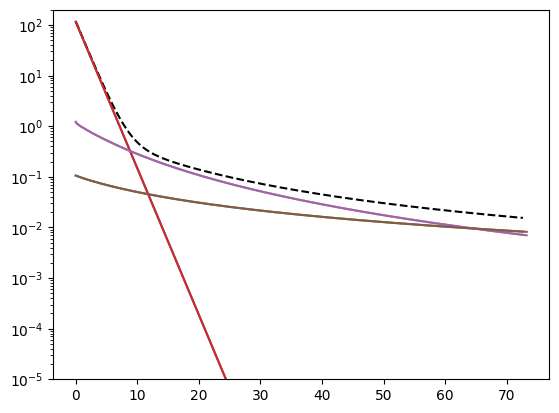

In [38]:
# Production Rates [grid]
P_true = np.array(Dome_C.COS_Production(h_acc/Dome_C.rho_ice))
#P_m = np.array(Dome_C.COS_Production(p/Dome_C.rho_ice))
P_m = P_true @ delta_Ap1_inv.T
P = P0_tuning @ P_m
plt.plot(h_p, (P0_tuning[:,None]*P_m).T)
plt.plot(h_p, P, ls='--', c='k')
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pn'][:,-1])
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmu'][:,-1])
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmuf'][:,-1])
plt.yscale('log')
plt.ylim(1e-5,2e2)

In [39]:
# Accumulation Depths [bins]
# equally space in z
if New:
    age_bins = t1_bins-t1_bins[0]
    age = (age_bins[:-1]+age_bins[1:])/2
    dage = np.diff(age_bins)
    dage_bins = smooth_diff(age_bins)

    h_bins = np.interp(age_bins, age_grid, h_grid)
    h = (h_bins[:-1]+h_bins[1:])/2
    dh = np.diff(h_bins)
    dh_bins = smooth_diff(h_bins)

    z_bins = np.interp(age_bins, age_grid, z_grid)
    z = (z_bins[:-1]+z_bins[1:])/2
    dz = np.diff(z_bins)
    dz_bins = smooth_diff(z_bins)
else:
    z = z_grid
    dz = smooth_diff(z)
    
    h = h_grid
    dh = smooth_diff(h)
    
    age = age_grid
    dage = smooth_diff(age)

age.shape

(441,)

In [40]:
# Sample Depths [bins]

sample_widths = np.array([20]*len(z_exp)) #widths of ice core sample depth ranges [m]

z_samp_bins = z_exp[None,:] + sample_widths[None,:]*np.array([-0.5,0.5])[:,None]
#z_samp_bins = Prop_DC.z_samp_bins
z_samp = (z_samp_bins[0]+z_samp_bins[1])/2
dz_samp = z_samp_bins[1]-z_samp_bins[0]

h_samp_bins = np.interp(z_samp_bins, z_grid, h_grid)
h_samp = (h_samp_bins[0]+h_samp_bins[1])/2
dh_samp = h_samp_bins[1]-h_samp_bins[0]

#axis0 - Lower/Upper Bound (0-lower, 1-upper)
#axis1 - Sample bin (s)
z_samp_bins.shape

(2, 16)

# Calculate Site Variables

## Density & Porosity Profile

Define the ice density profile of Dome C and the open, closed, total porosity $s$ with depth.

$$\rho(z) = dh(z)/dz$$

$$s(z) = 1-\rho(z)/\rho_{ice}$$

$$s_c(z) = 0.37s(z) * (\frac{s(z)}{1-\rho_{co}/\rho_{ice}})^{-7.6}$$

$$s_o(z) = s(z) - s_c(z)$$

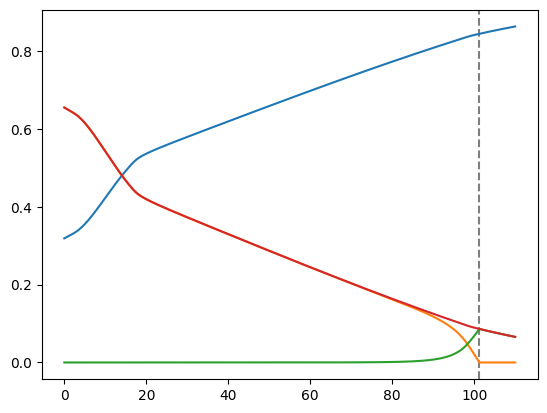

In [41]:
# Calculate Densities and Porosities

rho = dh/dz
if not New:
    rho = Dome_C.rho
rho_ice = max(0.9165 - (Dome_C.T-273.15)*1.4438e-4 - (Dome_C.T-273.15)**2 * 1.5175e-7, max(rho)+1e-9) # Schwander et al.
rho_co = 0.833 # density at close off depth? idk

s = 1 - rho/rho_ice # porosity of ice by depth
s_closed = (0.37 * s * (s/(1-rho_co/rho_ice))**(-7.6)).clip(max=s) # closed porosity
s_open = s - s_closed # open porosity

teller_co = np.argmax(s_closed) # depth index of maximum closed porosity (close off depth??)

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z,rho)
plt.plot(z,s_open)
plt.plot(z,s_closed)
plt.plot(z,s)

## Tortuosity & Diff_m

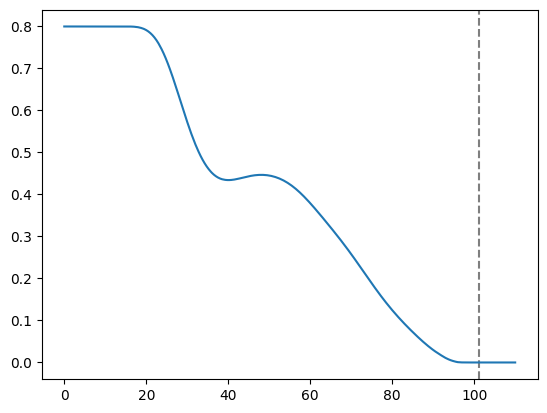

In [42]:
# Load InvTort and Diff_m from csv

tort_file = 'Firn_Model_Tortuosity_DomeC.csv'
Profiles = np.array(pd.read_csv(tort_file))
InvTort = np.interp(z, Profiles[:,0], Profiles[:,1]) # inverse Tortuosity D(z) = D^0 * Inv tort
Diff_m = np.interp(z, Profiles[:,0], Profiles[:,2]) # dispersive mixing in lock-in zone

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, InvTort)

## Bubble Pressure & Velocity

$$v_{ice}(z) = dz/dage = Acc/\rho$$

In the firn, we calculate the bubble pressure by the integral:

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z')/ (1+\int_{z'}^z \frac{d\ln v_{ice}(z'')}{dz''} dz'')dz'}{s(z)\int_0^z \frac{ds_c(z')}{dz'} dz'} $$

I can't help but notice we're taking the integral of derivatives here.  Makes it pretty easy to simplify,

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z') /(1+\ln v_{ice}(z) - \ln v_{ice}(z'))dz'}{s(z)[s_c(z)-s_c(0)]}$$

We also calculate the flux of air through the close-off depth:

$$flux = b_p(z_{co+1}) s_c(z_{co+1}) v_{ice}(z_{co+1})$$

The velocity:

$$v(z) = \begin{cases}\displaystyle
\frac{flux - v_{ice} * b_p * s_c}{C * s_o} & <v_{ice}(z)\\
v_{ice}(z) & \text{else}
\end{cases}$$

And the air content:

$$a_c = 1000 * \frac{b_p(z_{co+1}) * s_c(z_{co+1})}{\rho(z_{co+1})} * \frac{pressure}{101325} * \frac{273.15}{T}$$

/tmp/ipykernel_1778/1421640894.py:26: RuntimeWarning: invalid value encountered in divide
  bubble_pres = np.sum((dscl * C_air * s)[None,:] * dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(s*(s_closed-s_closed[0]))


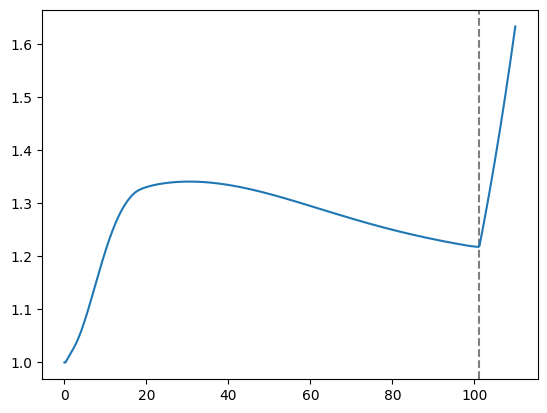

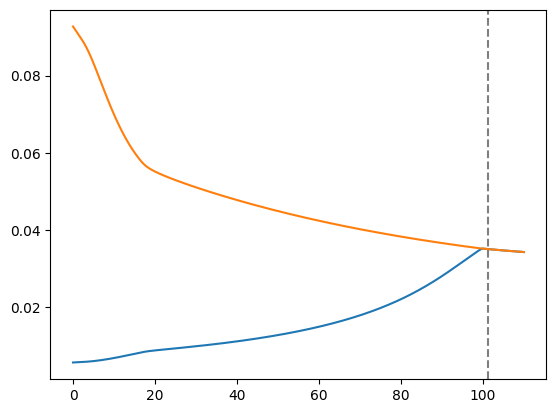

In [43]:
Site = Dome_C

g = Site.g
R = Site.R
T = Site.T
pressure = Site.pressure
M_air = Site.M_air
H_eddy = Site.H_eddy
D_0eddy = Site.D_0eddy

#dscl = smooth_diff(s_closed)/dz # ds_closed / dz
dscl = np.diff(s_closed, prepend=s_closed[0])/dz # ds_closed / dz

C_air = np.exp(M_air * g * z / (R * T) )
if New:
    Acc = np.mean(dh/dage)
else:
    Acc = Dome_C.Acc * Dome_C.rho_ice
v_ice = Acc / rho # downwards ice velocity
#v_ice = dz/dage

#strain = smooth_diff( np.log(v_ice))/dz # d log(v_ice) / dz
#strainsum = scipy.integrate.cumulative_trapezoid(strain, dx=self.dz, initial=0)
strainsum = np.log(v_ice)
i = np.arange(len(z))
bubble_pres = np.sum((dscl * C_air * s)[None,:] * dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(s*(s_closed-s_closed[0]))
# Divide by zero error at the first index, so we set that to 1
bubble_pres[0] = 1 # what are the units here??

# After teller_co:
bubble_pres[teller_co+1:] = bubble_pres[teller_co] * s[teller_co] / s[teller_co+1:] * v_ice[teller_co] / v_ice[teller_co+1:]
# bubble pres is directly inverse to s and v_ice below close-off depth

flux = v_ice[teller_co+1] * bubble_pres[teller_co+1] * s_closed[teller_co+1]

velocity = np.minimum(v_ice, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air) )
velocity = velocity#/(60*60*24*365.25) # convert to m/s

#never used:
#air_content = 1000 * bubble_pres[teller_co+1] * s_closed[teller_co+1] * pressure / 101325 * 273.15 / T / rho[teller_co+1]

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, bubble_pres)
#plt.plot(z, Dome_C.bubble_pres)
#plt.yscale('log')
plt.show()

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, velocity)#*(60*60*24*365.25))
#plt.plot(z, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air))
plt.plot(z, v_ice)
#plt.plot(z, Dome_C.v_ice)
plt.show()

## Crank Nicholson Parameters

The differential equation describing the diffusion of our open porosity gas concentration $c$ is:

$$\frac{\partial c}{\partial t} = \alpha\frac{\partial^2 c}{\partial z^2} + \beta\frac{\partial c}{\partial z} + \gamma c$$

where

$$\alpha = D + D_e$$

$$\beta = \frac{[D*(M_{air}-M_{^{14}CO}) + D_e*M_{air}]*g}{R*T} + \frac{d((D+D_e)*C_{air}*s_o)}{s_o*C_{air}\,dz} - v$$

$$\gamma = \frac{d(D*C_{air}*s_o)}{s_o*C_{air}\,dz}\frac{(M_{air}-M_{^{14}CO})*g}{R*T} - \lambda$$

$D = InvTort * D_{trace}$ - Diffusivity

$D_e$ - Eddie diffusivity

$C_{air} = e^{M_{air}gz/RT}$ - "Barometric equation", open porosity pressure relative to surface, I think?

$M_{air}$ - molar mass of air

$M_{trace}$ - molar mass of $^{14}$CO

$L_{trace}$ - decay rate of $^{14}$CO

The function below calculates $\alpha' = \alpha \frac{dt}{2dz^2}$, $\beta' = \beta \frac{dt}{4dz}$, and $\gamma' = \gamma \frac{dt}{2}$, for reasons that will be explained in the following section.

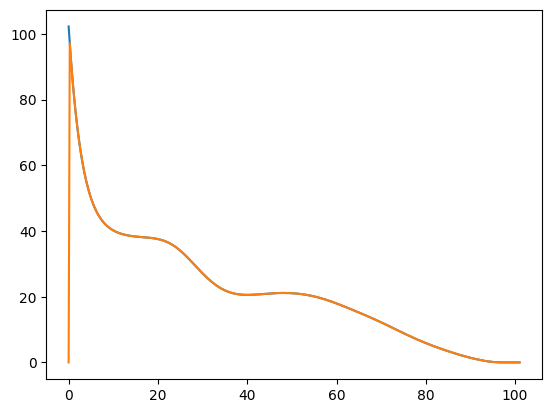

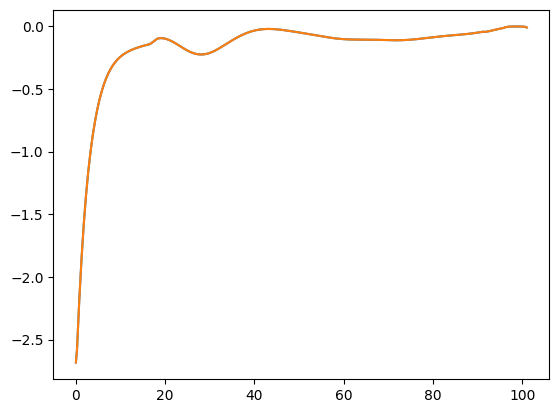

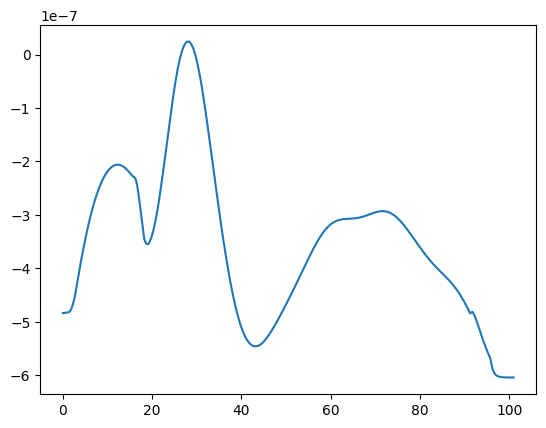

In [44]:
gas = 'C14_CO'
Site = Dome_C

L_trace = lambd/(60*60*24*365.25)
M_air = Site.M_air
g = Site.g
R = Site.R
T = Site.T

Q = teller_co

# Molecular diffusivity part:
Diff   =  InvTort * Site.D_gas[gas]

M_trace = Site.M_gas[gas]

# Eddy diffusivity part:
Diff_e = efilter(D_0eddy*np.exp(-z/H_eddy),0.5/np.diff(z))*(z<55) # Convection following Kawamura et al
Diff_e = np.maximum(Diff_e, Diff_m)    # Add dispersion in the LIZ

# Take the derivatives
porecl = smooth_diff(Diff*C_air*(s_open+1e-9))/dz/((s_open+1e-9)*C_air)#.clip(min=1e-20)
porecl_e = smooth_diff(Diff_e*C_air*(s_open+1e-9))/dz/((s_open+1e-9)*C_air)#.clip(min=1e-20)

porecl[teller_co]   = porecl[teller_co+1]
porecl_e[teller_co] = porecl_e[teller_co+1]

# c_t = alpha*c_zz + beta*c_z + gamma*c

alpha =  (dt_D*60*60*24*365.25/2/dz**2) * (Diff+Diff_e)
alpha2 =  (dt_D*60*60*24*365.25/2) * (Diff+Diff_e)
alpha2[1:-1] = alpha2[1:-1] / ((z[2:]-z[1:-1])*(z[1:-1]-z[:-2])*(z[2:]-z[:-2])/2)
alpha2[[0,-1]] = 0

beta  =  (dt_D*60*60*24*365.25/4/dz) * (Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity/(60*60*24*365.25))
beta2  =  (dt_D*60*60*24*365.25/4/smooth_diff(z)) * (Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity/(60*60*24*365.25))

gamma =  (dt_D*60*60*24*365.25/2) * (porecl*(M_air-M_trace)*g/(R*T) +  -L_trace)

plt.plot(z[:Q], alpha[:Q])
plt.plot(z[:Q], alpha2[:Q]*(z[1:Q+1]-z[:Q]))
plt.show()

plt.plot(z[:Q], beta[:Q])
plt.plot(z[:Q], beta2[:Q])
plt.show()

plt.plot(z[:Q], gamma[:Q])
plt.show()

## Crank-Nicholson Matrix

To solve the diffusion PDE:

$$\frac{\partial}{\partial t}c = \alpha\frac{\partial^2}{\partial z^2}c + \beta\frac{\partial}{\partial z}c + \gamma c$$

We approximate our spatial derivates as the average between timesteps $t+1$ and $t$:

$$\frac{c^{t+1}-c^t}{\Delta t} = \frac{\alpha}{2(\Delta z)^2}((c^{t+1}_{i+1}-2c^{t+1}_i+c^{t+1}_{i-1})+(c^t_{i+1}-2c^t_i+c^t_{i-1})) + \frac{\beta}{4\Delta z}((c^{t+1}_{i+1}-c^{t+1}_{i-1})+(c^t_{i+1}-c^t_{i-1})) + \frac{\gamma}{2}(c^{t+1}_i + c^{t}_i)$$

Moving our timesteps $t+1$ and $t$ to opposite sides of the equation,

$$-(\alpha' + \beta')c^{t+1}_{i+1} + (1 + 2\alpha' - \gamma')c^{t+1}_i - (\alpha' - \beta')c^{t+1}_{i-1} = (\alpha' + \beta')c^{t}_{i+1} + (1 - 2\alpha' + \gamma')c^{t}_i + (\alpha' - \beta')c^{t}_{i-1}$$

We can rewrite this as a matrix product on $c^{t+1}$ and $c^t$:

$$A_{i,i-1} = \alpha'_i - \beta'_i; \quad A_{i,i} = -2\alpha'_i + \gamma'_i; \quad A_{i,i+1} = \alpha'_i + \beta'_i$$

$$(I-A)c^{t+1} = (I+A)c^t$$

Which we can solve by inversion:

$$c^{t+1} = (I-A)^{-1}(I+A)c^t$$

The ice starts uniformly filled with the same $^{14}$CO concentration as the atmosphere.

After each timestep, the concentration at the top of the ice is set to the current atmospheric $^{14}$CO concentration.

Cosmogenic $^{14}$CO is also being injected into our gas, so after each timestep we add the extra $^{14}$CO leaking out of the grains.

In [45]:
Q = teller_co+20

#"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha[1:Q-1] - beta[1:Q-1], [0])),
        np.concatenate(([1], 1-2*alpha[1:Q-1]+gamma[1:Q-1], [0])),
        np.concatenate(([0], alpha[1:Q-1] + beta[1:Q-1] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha[1:Q-1] - beta[1:Q-1]), [-1])),
        np.concatenate(([1], 1+2*alpha[1:Q-1]-gamma[1:Q-1], [1])),
        np.concatenate(([0], -1*(alpha[1:Q-1] + beta[1:Q-1]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha2[1:Q-1]*(z[2:Q]-z[1:Q-1]) - beta2[1:Q-1], [0])),
        np.concatenate(([1], 1-alpha2[1:Q-1]*(z[2:Q]-z[:Q-2])+gamma[1:Q-1], [0])),
        np.concatenate(([0], alpha2[1:Q-1]*(z[1:Q-1]-z[:Q-2]) + beta2[1:Q-1] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha2[1:Q-1]*(z[2:Q]-z[1:Q-1]) - beta2[1:Q-1]), [-1])),
        np.concatenate(([1], 1+alpha2[1:Q-1]*(z[2:Q]-z[:Q-2])-gamma[1:Q-1], [1])),
        np.concatenate(([0], -1*(alpha2[1:Q-1]*(z[1:Q-1]-z[:Q-2]) + beta2[1:Q-1]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()
#"""

A_inv = np.linalg.inv(A_back)
D = A_inv @ A_for
D[0] = 0
D1 = np.copy(D)
D = np.linalg.matrix_power(D,int(dt1/dt_D))
D.shape

(425, 425)

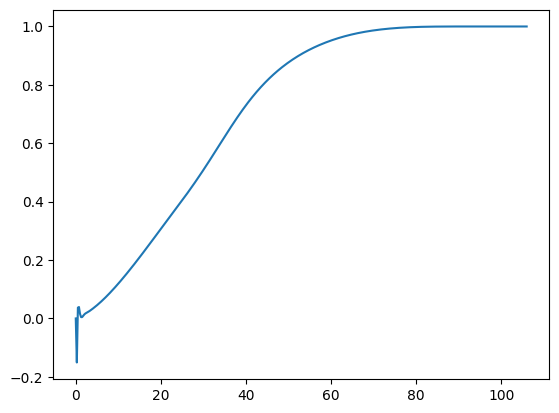

In [46]:
plt.plot(z[:Q], np.sum(D, axis=1))

In [47]:
N_D = int(1000/dt1) # maximum number of diffusion timesteps worth considering
D_t = np.moveaxis(cum_mat_prod(D,N_D),0,-1)
#D_t = np.moveaxis(cum_mat_prod(np.linalg.matrix_power(Dome_C.D,int(dt1/dt_D)),N_D),0,-1)
D_t.shape

100%|███████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 1353.54it/s]


(425, 425, 1000)

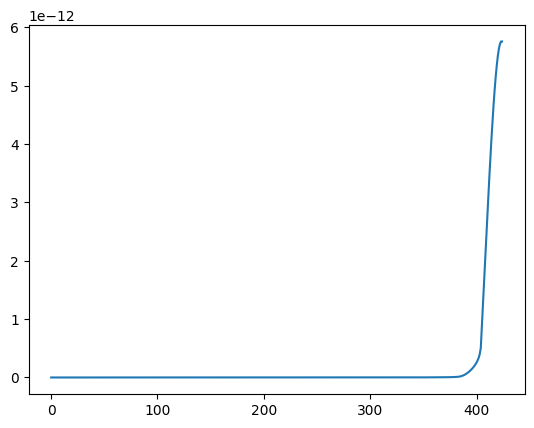

In [48]:
# after ~200 years only ~1e-6 of 14CO is left
# after ~300 years it's ~1e-9
plt.plot(np.sum(D_t[:,:,-1],axis=-1))

## Unit Conversions g<->ppm

/tmp/ipykernel_1778/351948400.py:3: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)


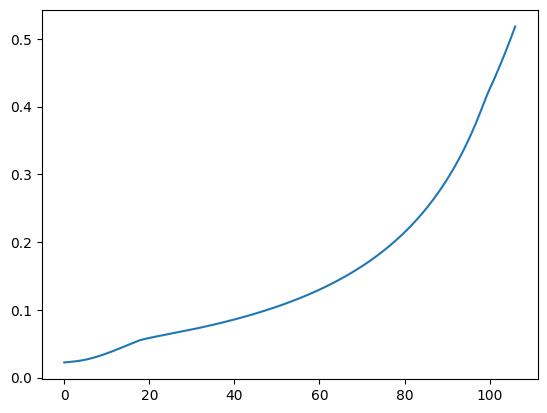

In [49]:
pressure = Dome_C.pressure

gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)
gram_to_ppm[teller_co:] = 0

#U = (gram_to_ppm * (delta_pa @ delta_ap @ s_open)/(delta_pa @ delta_ap @ s))[:Q]
U = 1e18*R*T / (6.022140857e23*pressure*s[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)
plt.plot(z[:Q], U)

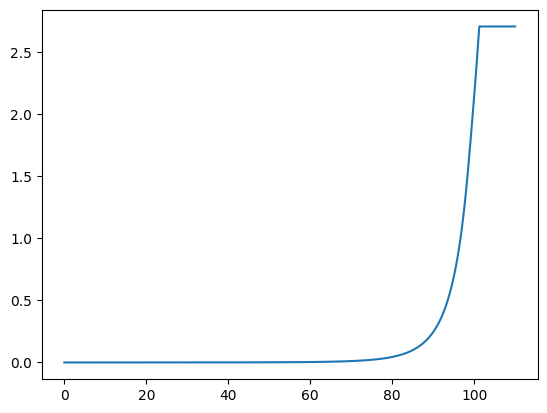

In [50]:
ppm_to_gram_cl = (6.022140857e23 * pressure * s_closed / rho * bubble_pres * 1e-6)/(1e18*R*T)
plt.plot(z, ppm_to_gram_cl)

## Trapping Rate

The trapping rate of open porosity gas into closed porosity gas is given by the change in the number density of closed porsosity gas particles per unit time:

$$trapping(z) = \rho(z)\frac{d(s_c*b_p)}{dz}$$

Since all of these new gas particles entering the closed porosity of our ice parcel come from the open porosity, the additional $^{14}$CO concentration ($c(z)$) they bring is the integral over time of the open porosity concentration ($c_o(z,t)$) times the trapping rate ($tr(z)$) times the fraction of $^{14}$C which has since decayed ($e^{-\lambda (t-t')}$), divided by the total gas in closed porosity ($\int_{t_0}^t tr(z(t'))\,dt'$).

$$c(z,t) = \frac{\int_{t_0}^{t} c_o(z(t'),t')\,tr(z(t'))\,e^{-\lambda (t-t')}\,dt'}{\int_{t_0}^t tr(z(t'))\,dt'}$$

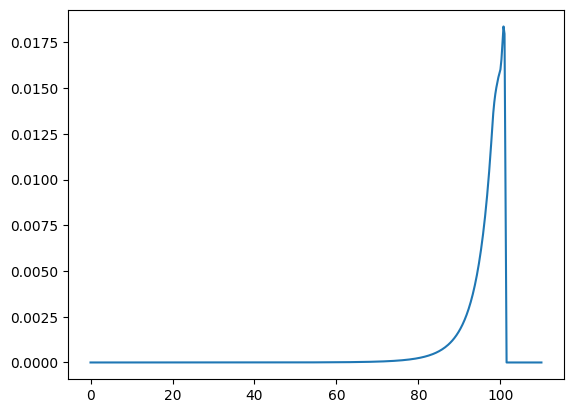

In [51]:
trapping_t = rho*smooth_diff(s_closed*bubble_pres/rho)/dz # Acc*rho_ice/v_ice = Acc*rho_ice/(Acc*rho_ice/rho) = rho
plt.plot(z, trapping_t)

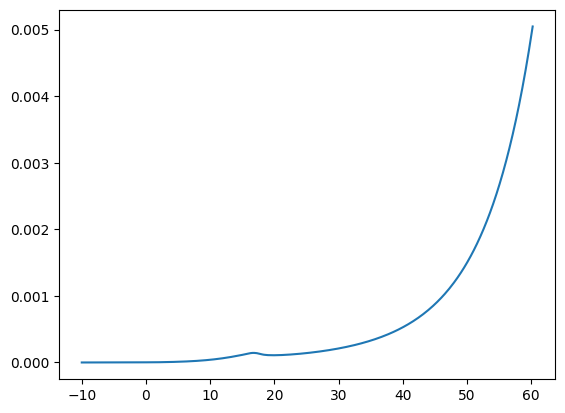

In [52]:
dt2 = dt1
t2 = t1-t1[0]
z_hist = np.interp(age[:,None] - t2[None,:], age, z, left=-10)

M_trapping = np.interp(z_hist, z, trapping_t, left=0)
M_Trap = M_trapping/np.sum(M_trapping*dt2,axis=1,keepdims=True)

i=-200
plt.plot(z_hist[i],M_Trap[i])

## Interpolation Matrices

$\hat{H}$ - accumulation depth interpolation operator (interpolates production depths to h'(h,t))

$$H_i(h') = (\frac{h'-h_{i-1}}{h_i-h_{i-1}}).\text{clip}(0,1) - (\frac{h'-h_{i}}{h_{i+1}-h_{i}}).\text{clip}(0,1)$$

$h'(h,t)$ - depth at time $t$ of ice parcel w/ present accumulation depth $h$

$h_i$ - propagation depths (for $i$<0 or $i$>max, replace the terms with $h'\geq h_0$ and $h'>h_{\text{max}}$, respectively)

Is the transpose the same as the inverse?

iff the matrix is orthonormal

In [53]:
#Interpolate from production depths (p) to accumulation depths (a)
#delta_pa = interp_mat(h[:,None],p[None,:])
delta_pa = interp_mat(z[:,None],p_z[None,:])
#axis0 - accumulation depth (a)
#axis1 - production depth (p)
delta_pa.shape

(441, 2478)

In [54]:
#Interpolate from production depths (p) to accumulation depths (a)
#delta_ap = interp_mat(p[:,None],h[None,:])
delta_ap = interp_mat(p_z[:,None],z[None,:])
#axis0 - production depth (p)
#axis1 - accumulation depth (a)
delta_ap.shape

(2478, 441)

In [55]:
delta_Ad = interp_mat(z_acc[:,None], z[None,:])
delta_Ad.shape

(4915, 441)

In [56]:
delta_dA = interp_mat(z[:,None], np.array([0,*z_acc])[None,:])[:,1:]
delta_dA[-1,-1]=1
delta_dA.shape

(441, 4915)

## Sample Average Matrix

$\hat{S}$ - sample operator (averages over each sample depth range in accumulation depth)

$$S(s,h) = \frac{(s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}{\sum_h (s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}$$

$s$ - sample depth bins (+ upper bound, - lower bound)

$h$ - accumulation depth bins (- lower bound, $\Delta$ width)

In [57]:
S_mat = (h_samp_bins[1,:,None]-h[None,:]).clip(0,dh[None,:]) - (h_samp_bins[0,:,None]-h[None,:]).clip(0,dh[None,:])
S_mat /= np.sum(S_mat, axis=-1, keepdims=True)
#axis0 - Sample Depth
#axis1 - Accumulation Depth
S_mat.shape

/tmp/ipykernel_1778/4240440307.py:2: RuntimeWarning: invalid value encountered in divide
  S_mat /= np.sum(S_mat, axis=-1, keepdims=True)


(16, 441)

# Accumulation Tensors

$$\vec{c}_f = e^{-\lambda \vec{age}_f} (1-L)^{\vec{age}_f} \sum_{t'}^{\vec{age}_f} C^{\text{add}}_{t'} e^{\lambda t'} (1-L)^{-t'}$$

$$\vec{c}^{\text{equil.}}_f = (I-D)^{-1}_{fi} \cdot \vec{c}^{\text{add}}_i$$

$$\vec{c}_f = \vec{c}_f$$

$$\vec{c}_f = \sum_{m,r} \vec{c}^{\text{cos}}_{f,m,r}\vec{f}_m\vec{R}_r + \vec{c}^{\text{atm}}_f C^{\text{atm}}$$

$$\vec{c}_f = \sum_{p,t,r}\hat{A}_{f,p,t,r}\vec{P}_p\vec{\phi}_t\vec{R}_r + \sum_t \hat{A}^{\text{atm}}_{f,t}\vec{C}^{\text{atm}}_t$$

## Grains

In tensor form:

$$\vec{c}^{\text{grains}}_f = \sum_{p,t,r}\hat{A}^{\text{grains}}_{f,p,t,r}\vec{P}_p\vec{\phi}_{t} \vec{R}_r$$

$$\hat{A}^{\text{grains}}_{a,p,t,r} = (1-\vec{L}_r)^{-t}e^{\lambda t}dt\, \hat{\delta}_{f,a-t}\cdot \hat{\delta}_{a,p}$$

where $\hat{\delta}_{a+t',p} = \hat{\delta}_{a,p'}\hat{\delta}_{p'+t',p}$ acts as a linear interpolation from depth $p$ to $a+t'$ (from $z^{prod}_p$ to $z(age(z_a)+t')$)

$\vec{L}_r$ - annual leakage rate of reservoir $r$

In [58]:
#A_grains = (1-L[:,None])**(-t1[None,:]+dt1) * np.exp(lambd*(t1[None,:]-dt1)) * dt1
#axis0 - leakage rate (L)
#axis1 - production time (t1)
#A_grains.shape

In [59]:
#i = np.arange(len(p))
#j = np.arange(len(p))
#k = np.arange(len(t1))-len(t1)
#delta_ppt1 = i[None,None,:] == j[None,:,None] + k[:,None,None]
#axis0 - production time (k)
#axis1 - present depth (j)
#axis2 - past depth (i)
#delta_ppt1.shape

In [60]:
#A_grains_const = np.einsum('ai, tip, lt -> lap', delta_pa, delta_ppt1, A_grains, optimize=True)
#A_grains_const = np.zeros((len(L), len(z), len(p)))
#for i in tqdm(np.arange(len(t1))-len(t1)):
    #A_grains_const[:,:,:i] += delta_pa[None,:,-i:] * A_grains[:,i,None,None]
#A_grains_const[:,:,1:] = (A_grains_const[:,:,:-1]+A_grains_const[:,:,1:]*2.95)/(1+2.95)
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)

In [61]:
delta_aA = interp_mat(z[:,None],np.array([0,*z_acc])[None,:])[:,1:]
delta_Ap = interp_mat(h_acc[:,None],h_p[None,:])

t = -np.arange(len(z_acc))-1
A_grains_const = np.zeros((len(L), len(z), len(z_acc)))

for i in tqdm(t):
    A_grains_const[:,:,:i] += delta_dA[None,:,-i:] * (1-L[:,None,None])**(-i*dt_acc)* np.exp(lambd*i*dt_acc) * dt_acc
A_grains_const = A_grains_const @ delta_Ap1
A_grains_const.shape

100%|██████████████████████████████████████████████████████████████████████████████| 4915/4915 [00:33<00:00, 144.64it/s]


(2, 441, 2458)

[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

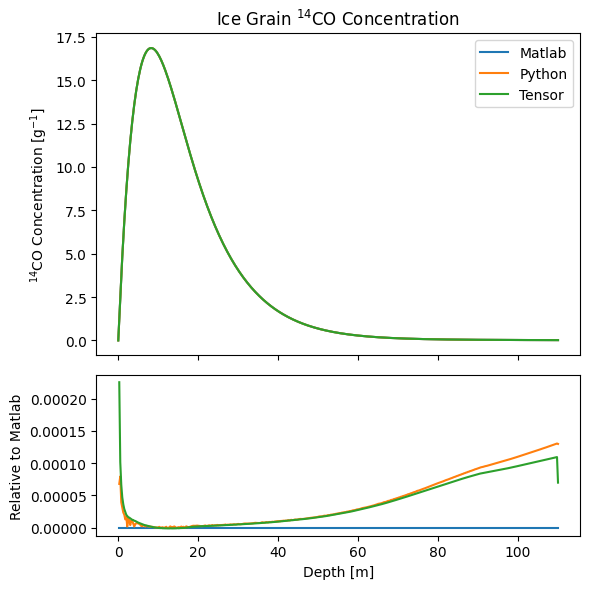

In [68]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

#plt.plot(z, np.einsum('lapt, t, p, l -> a', A_grains_full, phi, P, Res, optimize=True))
axes[0].plot(runMat['z'], runMat['C14_grains'][:,-1,1], label='Matlab')
axes[0].plot(Dome_C.z, P0_tuning @ C14_grains @ Res, label='Python')
axes[0].plot(z, np.einsum('lap, p, l -> a', A_grains_const, P, Res, optimize=True), label='Tensor')
axes[0].legend()

axes[1].plot(runMat['z'][1:], runMat['C14_grains'][1:,-1,1]/runMat['C14_grains'][1:,-1,1]-1)
axes[1].plot(z[1:], (P0_tuning @ C14_grains @ Res)[1:]/runMat['C14_grains'][1:,-1,1]-1)
axes[1].plot(z[1:], np.einsum('lap, p, l -> a', A_grains_const, P, Res, optimize=True)[1:]/runMat['C14_grains'][1:,-1,1]-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Ice Grain $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

## Open Porosity

$$\vec{c}^{open}_{a,t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{open})_{a,p,t'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t'+t}$$

$$\hat{A}^{\text{open}}_{f,p,t,r} = [\sum_{t'=0}^{\text{age}_{co}} (\hat{\delta}_{f,d}D^t U \hat{\delta}_{d,a})_{f,a+t',-t-t'} e^{-\lambda t'}(1-\vec{L}_r)^{t'}(1-(1-\vec{L}_r)^{dt'})]dt\cdot \hat{\delta}_{a,p}$$

$t''$ - leak time; time spent in grain before leaking into open pores, can't be longer than age at close-off depth

$p+t''$ - leak depth; depth at which 14CO produced at depth $p$ leaks into open pores ($z^{prod}_{p+t''}=z(age(z^{prod}_p)+t'')$ since $z^{prod}$ corresponds to $t''$)

$-t'-t''$ - diffusion time; time spent diffusing in open porosity before measurement

$\vec{L}_r$ - annual leakage rate of reservoir $r$

$\hat{\delta}_{a,p}$ - linear interpolation from production depth $p$ to accumulation depth $a$

$$D^t_{a,a',t'''} = [\sum_{t_D=0}^{dt'''} D^{t_D} \frac{dt_D}{dt'''}]D^{t'''}$$

$D^t_{a,a',t'''}$ - Diffusion of 14CO introduced at depth $a'$ to depth $a$, for a duration averaged between $t'''$ and $t'''+dt'''$ years, with subdivided timestep $dt_D$

$D^{dt}$ - Diffusion matrix for timestep $dt$

$$U_a = U_{g\rightarrow ppm}(a) \frac{s_o(a)}{s(a)}$$

$U(a)$ - open porosity fraction * unit conversion from per gram to ppm at depth $a$

In [69]:
#Interpolate from production depths (p) to past accumulation depths (a'=a+At)
#dt2 = dt1
#t2 = np.arange(int(age[Q]/dt2))*dt2
#h_hist = np.interp(age[None,:Q,None] - t2[:,None,None], age_grid, h_grid, left=-10)
#delta_pahist = interp_mat(h_hist, p[None,p<=h[teller_co+1]])
#axis0 - grain time (t2)
#axis1 - past accumulation depth (a')
#axis2 - production depth (p)
#delta_pahist.shape

In [70]:
# apply our unit conversion ahead of time
# to avoid repetitive multiplication
DU = delta_pa[:Q,p<=h[teller_co+1]].T @ ((np.sum(cum_mat_prod(D1,int(dt1/dt_D)), axis=0).T @ D_t)*gram_to_ppm[None,:,None] * dt_D/dt1) * ((delta_ap @ s_open)/(delta_ap @ s).clip(min=1e-20))[None,p<=h[teller_co+1],None]
#axis0 - accumulation depth (a)
#axis1 - diffusion depth (p')
#axis2 - diffusion time (t3=-t1-t2)

100%|███████████████████████████████████████████████████████████████████████████████████| 99/99 [00:02<00:00, 43.78it/s]


In [71]:
A_open_atm = np.sum(cum_mat_prod(D1,int(dt1/Dome_C.dt)), axis=0)[:,0] @ D_t[:,:,::-1]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_open_atm.shape

100%|██████████████████████████████████████████████████████████████████████████████████| 99/99 [00:00<00:00, 985.15it/s]


(425, 1000)

In [72]:
# sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
A_open = np.zeros((len(L),Q,len(p[p<=h[teller_co+1]])))#,int(age[Q]/dt1)+N_D))
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)

DU_sum = np.sum(DU, axis=-1)

dt2 = dt1
t2 = np.arange(int(age[Q]/dt2))*dt2
for t2 in tqdm(range(len(t2))): #t2 = time spent in grains before leaking
    #A_open[:,:,:-t2 if t2>0 else None,t2:t2+N_D] += DU[None,:,t2:,::-1] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None,None]
    A_open[:,:,:-t2 if t2>0 else None] += DU_sum[None,:,t2:] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None]
    #A_open[:,:,:,t2:t2+N_D] += delta_pahist[t2].T @ DU[None,:,:,::-1] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None,None]
A_open *= (1-(1-L)**dt2)[:,None,None] * dt1
A_open = A_open @ delta_pp1[p<h[teller_co+1]]

#t1_cut = t1[-int(age[Q]/dt1):]
#dt3 = dt1
#for t3 in tqdm(range(N_D)):
    #A_open[:,:,:,N_D-t3-1:-t3-1] += np.moveaxis(DU[:,:,t3] @ delta_pahist[N_D-t3-1:-t3-1], 0,-1)[None,:,:,:] * (np.exp(lambd*(t1_cut[None,:]+t3*dt3)) * (1-L[:,None])**(-(t1_cut[None,:]+t3*dt3)))[:,None,None,:]
#A_open *= (1-(1-L)**dt3)[:,None,None,None] * dt1
#A_open = delta_pa.T[:,:Q] @ A_open
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_open.shape

100%|██████████████████████████████████████████████████████████████████████████████| 2348/2348 [00:04<00:00, 475.85it/s]


(2, 425, 2458)

[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

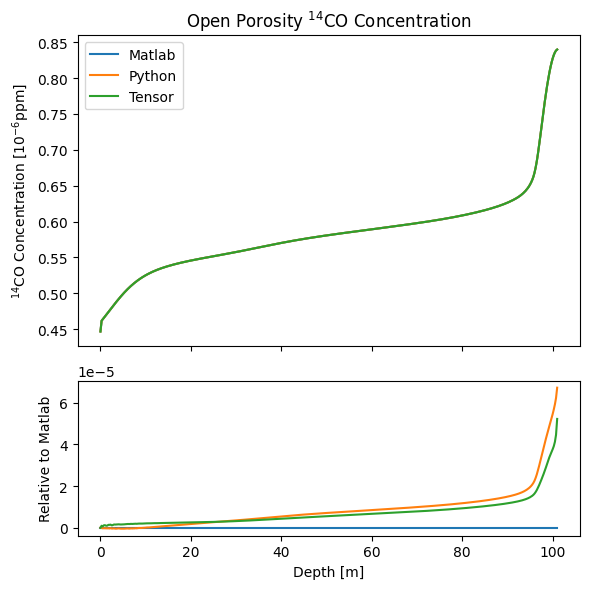

In [73]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

#plt.plot(z[:teller_co], (np.sum(A_open[:,:teller_co], axis=-1)@P[p<h[teller_co+1]]).T @ Res + A_open_atm[:teller_co] @ gas_history[-N_D:])
axes[0].plot(runMat['z'], runMat['c_open'][:,-1], label='Matlab')
axes[0].plot(Dome_C.z[:Dome_C.teller_co], P0_tuning @ (c_gases[:Dome_C.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Dome_C.teller_co,0], label='Python')
axes[0].plot(z[:teller_co], (A_open[:,:teller_co]@P).T @ Res + A_open_atm[:teller_co] @ gas_history[-N_D:], label='Tensor')
axes[0].legend()

#plt.plot(z[:teller_co], ((np.sum(A_open[:,:teller_co], axis=-1)@P[p<h[teller_co+1]]).T @ Res + A_open_atm[:teller_co] @ gas_history[-N_D:])/runMat['c_open'][:teller_co,-1]-1)
axes[1].plot(runMat['z'][:teller_co], runMat['c_open'][:teller_co,-1]/runMat['c_open'][:teller_co,-1]-1)
axes[1].plot(Dome_C.z[:Dome_C.teller_co], (P0_tuning @ (c_gases[:Dome_C.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Dome_C.teller_co,0])/runMat['c_open'][:teller_co,-1]-1)
axes[1].plot(z[:teller_co], ((A_open[:,:teller_co]@P).T @ Res + A_open_atm[:teller_co] @ gas_history[-N_D:])/runMat['c_open'][:teller_co,-1]-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [$10^{-6}$ppm]',
    title=r'Open Porosity $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

## Closed Porosity

$$\vec{c}^{closed}_{a,t} = \sum_{t',p} (\vec{R}\cdot[\hat{A}^{closed} + \hat{A}^{trap}])_{a,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t+t'} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t+t'}$$

$$\hat{A}^{\text{closed}}_{f,p,t,r} = e^{\lambda t}dt[\sum_{t'=0}^{-t}\frac{s_c(z_{a+t'})}{s(z_{a+t'})}(1-L)^{t'}(1-(1-L)^{dt'})] \hat{\delta}_{f,a-t}\cdot \hat{\delta}_{a,p}$$

$t''$ - leak time (relative to production)

In [74]:
#dt2 = dt1
#t2 = t1-t1[0]

#i = np.arange(len(p))
#j = np.arange(len(t2))
#sc_cast = ((delta_ap @ s_closed)/(delta_ap @ s).clip(min=1e-20))[(i[:,None]+j[None,:]).clip(max=len(p)-1)]*(i[:,None]+j[None,:]<=len(p)-1)#/s_cast
# closed leak fraction at leak time

dt2 = dt_acc
t2 = np.arange(len(z_acc))*dt_acc
i = np.arange(len(z_acc))
j = np.arange(len(t2))
sc_frac = ((delta_Ad @ s_closed)/(delta_Ad @ s).clip(min=1e-20))
sc_cast = sc_frac[(i[:,None]+j[None,:]).clip(max=len(z_acc)-1)]*(i[:,None]+j[None,:]<=len(z_acc)-1)
#axis0 - production depth (p)
#axis1 - grain time (t2)

t = np.arange(len(z_acc))-len(z_acc)

A_closed = np.cumsum(
    sc_cast[None,:,:] * (1-L[:,None,None])**t2[None,None,:],
    axis=-1
)[:,:,::-1] * (1-(1-L)**dt2)[:,None,None] * np.exp(lambd * t * dt_acc)[None,None,:] * dt_acc
#axis0 - Leakage rate (L)
#axis1 - production depth (p)
#axis2 - production time (t1)
A_closed.shape

(2, 4915, 4915)

In [75]:
#A_closed_const = np.einsum('ai, tip, lpt -> lap', delta_pa, delta_ppt1, A_closed, optimize=True)
t = np.arange(len(z_acc))-len(z_acc)
A_closed_const = np.zeros((len(L), len(z), len(z_acc)))
for i in tqdm(t):
    A_closed_const[:,:,:i] += delta_dA[None,:,-i:] * A_closed[:,None,:i,i]
A_closed_const = A_closed_const @ delta_Ap1
A_closed_const.shape

100%|██████████████████████████████████████████████████████████████████████████████| 4915/4915 [00:30<00:00, 159.06it/s]


(2, 441, 2458)

[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

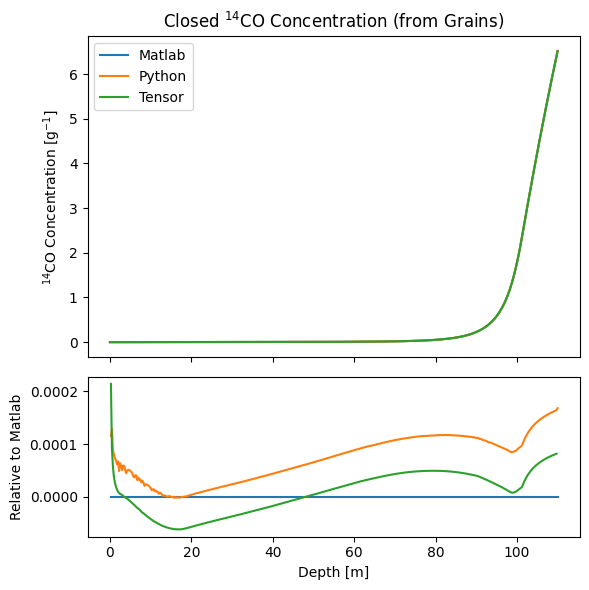

In [76]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

axes[0].plot(runMat['z'], runMat['C14_closed'][:,-2,1], label='Matlab')
axes[0].plot(Dome_C.z, P0_tuning @ (C14_cumuleak_closed) @ Res, label='Python')
axes[0].plot(z, (A_closed_const @ P).T @ Res, label='Tensor')
axes[0].legend()

axes[1].plot(runMat['z'][1:], runMat['C14_closed'][1:,-2,1]/runMat['C14_closed'][1:,-2,1]-1)
axes[1].plot(Dome_C.z[1:], (P0_tuning @ (C14_cumuleak_closed) @ Res)[1:]/runMat['C14_closed'][1:,-2,1]-1)
axes[1].plot(z[1:-1], ((A_closed_const @ P).T @ Res)[1:-1]/runMat['C14_closed'][1:-1,-2,1]-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Grains)',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
    #ylim=(-0.002,0.002),
)

[Text(0.5, 0, 'Depth [m]')]

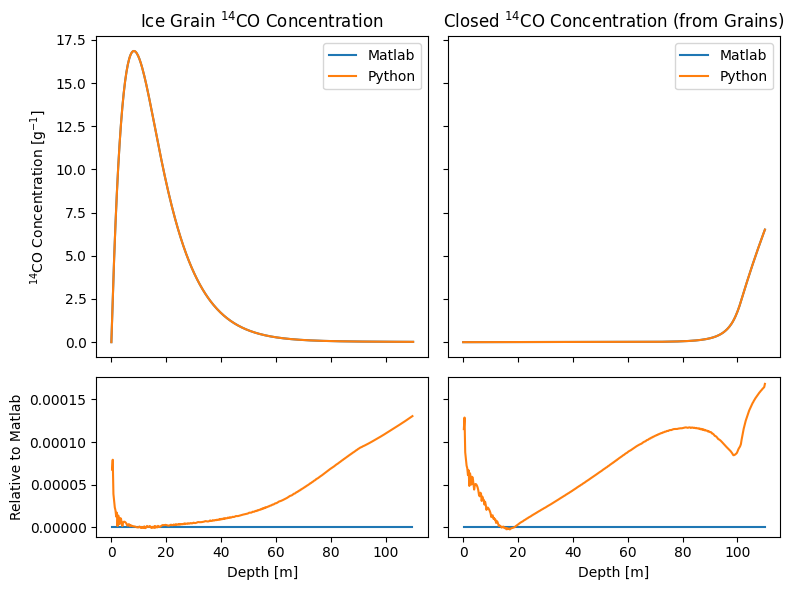

In [77]:
fig, axes = plt.subplots(2,2, figsize=(8,6), tight_layout=True, sharex = 'col', sharey='row', height_ratios=[2,1])

#plt.plot(z, np.einsum('lapt, t, p, l -> a', A_grains_full, phi, P, Res, optimize=True))
axes[0,0].plot(runMat['z'], runMat['C14_grains'][:,-1,1], label='Matlab')
axes[0,0].plot(Dome_C.z, P0_tuning @ C14_grains @ Res, label='Python')
#axes[0].plot(z, np.einsum('lap, p, l -> a', A_grains_const, P, Res, optimize=True), label='Tensor')
axes[0,0].legend()

axes[1,0].plot(runMat['z'][1:-1], runMat['C14_grains'][1:-1,-1,1]/runMat['C14_grains'][1:-1,-1,1]-1)
axes[1,0].plot(z[1:-1], (P0_tuning @ C14_grains @ Res)[1:-1]/runMat['C14_grains'][1:-1,-1,1]-1)
#axes[1].plot(z[1:-1], np.einsum('lap, p, l -> a', A_grains_const, P, Res, optimize=True)[1:-1]/runMat['C14_grains'][1:-1,-1,1]-1)


axes[0,1].plot(runMat['z'], runMat['C14_closed'][:,-2,1], label='Matlab')
axes[0,1].plot(Dome_C.z, P0_tuning @ (C14_cumuleak_closed) @ Res, label='Python')
#axes[0].plot(z, (A_closed_const @ P).T @ Res, label='Tensor')
axes[0,1].legend()

axes[1,1].plot(runMat['z'][1:], runMat['C14_closed'][1:,-2,1]/runMat['C14_closed'][1:,-2,1]-1)
axes[1,1].plot(Dome_C.z[1:], (P0_tuning @ (C14_cumuleak_closed) @ Res)[1:]/runMat['C14_closed'][1:,-2,1]-1)
#axes[1].plot(z[1:], ((A_closed_const @ P).T @ Res)[1:]/runMat['C14_closed'][1:,-2,1]-1)

axes[0,0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Ice Grain $^{14}$CO Concentration',
)

axes[1,0].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

axes[0,1].set(
    #ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Grains)',
)

axes[1,1].set(
    #ylabel='Relative to Matlab',
    xlabel='Depth [m]',
    #ylim=(-0.002,0.002),
)

$$\hat{A}^{trap}_{f,p,t,r} = U_{ppm\rightarrow g}(z_f)\hat{\delta}_{f,a}\cdot\sum_{t'}^{-t}e^{-\lambda t'}\frac{\text{tr}_{a-t'} dt'}{\sum^a_{t''} \text{tr}_{t''} dt''}\hat{\delta}_{a+t,f'}\cdot\hat{A}^{open}_{f',p,-t-t',r}$$

$$\hat{A}^{atm}_{a,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}e^{-\lambda t''}Tr(a,t'')\hat{\delta}_{a',a-At''}\hat{A}^{atm}_{a',-t'-t''}dt''$$

$t''$ - time in closed grain after getting trapped

Note: I think $U_{ppm\rightarrow g}$ should be applied at trapping depth, but in the firn model it is applied at final depth

In [78]:
A_trap_atm = np.zeros((len(z), len(t1)+N_D))
dt2 = dt1
t2 = t1-t1[0]
A_atm_interp = interp1d(z[:Q], A_open_atm, axis=0, bounds_error=False, fill_value=0, assume_sorted=True)
z_hist = np.interp(age[None,:] - t2[:,None], age, z, left=-10)

for t2 in tqdm(range(len(t2))):
    A_trap_atm[:,t2:t2+N_D] += np.exp(-lambd*t2*dt2) * M_Trap[:,None,t2] * A_atm_interp(z_hist[t2])[:,::-1] * dt2
A_trap_atm *= ppm_to_gram_cl[:,None]
A_trap_atm[:,len(t1)-1] += np.sum(A_trap_atm[:,len(t1):],axis=-1)
A_trap_atm = A_trap_atm[:,:len(t1)]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_trap_atm.shape

100%|██████████████████████████████████████████████████████████████████████████████| 3001/3001 [00:08<00:00, 356.71it/s]


(441, 3001)

In [79]:
N_op = A_open.shape[-1]
A_trap = np.zeros((len(L), len(z), len(h_p)))#, len(t1)+N_op))
p_lim = len(h_p[h_p<=h[teller_co+1]])
dt2 = dt1
t2 = t1-t1[0]
A_open_interp = interp1d(z[:Q], A_open[:,:,:p_lim], axis=1, bounds_error=False, fill_value=0, assume_sorted=True)
z_hist = np.interp(age[None,:] - t2[:,None], age, z, left=-10)

for t2 in tqdm(range(len(t1))):
    #A_trap[:,:,:p_lim,t2:t2+N_op] += np.exp(-lambd*t2*dt2) * M_Trap[None,:,None,None,t2] * A_open_interp(z_hist[t2])[:,:,:,::-1] * dt2
    A_trap[:,:,:p_lim] += np.exp(-lambd*t2*dt2) * M_Trap[None,:,None,t2] * A_open_interp(z_hist[t2])[:,:,:] * dt2
A_trap *= ppm_to_gram_cl[None,:,None]
#A_trap[...,len(t1)-1] += np.sum(A_trap[...,len(t1):],axis=-1)
#A_trap = A_trap[...,:len(t1)]
#axis0 - Leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_trap.shape

100%|███████████████████████████████████████████████████████████████████████████████| 3001/3001 [00:52<00:00, 57.33it/s]


(2, 441, 2458)

[Text(0, 0.5, 'Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

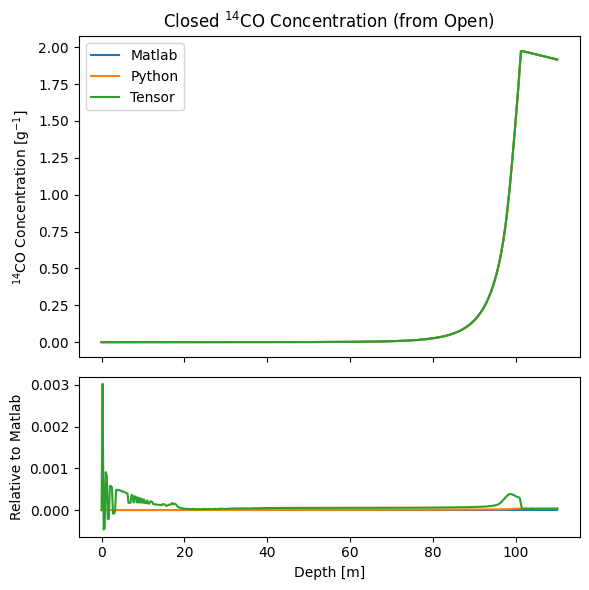

In [80]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

#plt.plot(z, Res @ np.sum(A_trap, axis=-1)@P + A_trap_atm @ gas_history)
axes[0].plot(runMat['z'], runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1], label='Matlab')
axes[0].plot(Dome_C.z, P0_tuning @ (C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'], label='Python')
axes[0].plot(z, Res @ (A_trap@P) + A_trap_atm @ gas_history, label='Tensor')
axes[0].legend()

axes[1].plot(runMat['z'], (runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])/(runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])-1)
axes[1].plot(Dome_C.z, (P0_tuning @ (C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])/(runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])-1)
axes[1].plot(z, (Res @ (A_trap@P) + A_trap_atm @ gas_history)/(runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])-1)

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Closed $^{14}$CO Concentration (from Open)',
)

axes[1].set(
    ylabel='Relative to Matlab',
    xlabel='Depth [m]',
)

$$\hat{A} = \hat{A}^{\text{grains}} + \hat{A}^{\text{closed}} + \hat{A}^{\text{trap}}$$

$$\Sigma^{\text{Pred}, P} = (\hat{A}\vec{\phi}\vec{R}) \cdot \Sigma^P\cdot (\hat{A}\vec{\phi}\vec{R})^T$$

$\log L = -\frac{1}{2} \Delta \vec{c}\, \Sigma^{-1}\Delta \vec{c} -\frac{1}{2} \log|2\pi\Sigma|$

$Z = \int L(\vec{\theta})p(\vec{\theta})\, d\vec{\theta};\text{ for params }\vec{\theta}$

$\text{p-value}(Z) = \text{prob}(Z’<Z);\text{ for rand }Z’$

$\log P = \log L + \log p - \log Z$

## Total Concentration

$$\hat{A}_{r,s,p,t'} = \hat{S}_{s,a}\cdot[\hat{A}^{grains}+\hat{A}^{closed}+\hat{A}^{trap}]_{r,a,p,t'}$$

$$\hat{A}^{atm}_{s,t'} = \hat{S}\cdot \hat{A}^{atm}$$

$$\vec{c}^{pred}_s = \sum_{t',p} (\vec{R}\cdot\hat{A})_{s,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'} + \sum_{t'}\hat{A}^{atm}_{s,t'}\vec{c}_{t'}^{atm}$$

$$\Sigma^{pred}_{ss'} = (\vec{R} \hat{A}\vec{\phi})_{s,p}(\vec{f}\Sigma^{prod}\vec{f}^T)_{p,p'}(\vec{R} \hat{A}\vec{\phi})^T_{p',s'} + (\hat{A}^{atm})_{s,t}\Sigma^{atm}_{t,t'}(\hat{A}^{atm})^T_{t',s'}$$

In [81]:
#A_profile = A_grains_const + A_closed_const + np.sum(A_trap,axis=-1)
A_profile = A_grains_const + A_closed_const + A_trap
#A_total = np.einsum('sa, la...->ls...', S_mat, A_profile)
#A_total.shape

In [82]:
#A_atm = S_mat @ A_trap_atm
#A_atm.shape

[Text(0, 0.5, '% Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

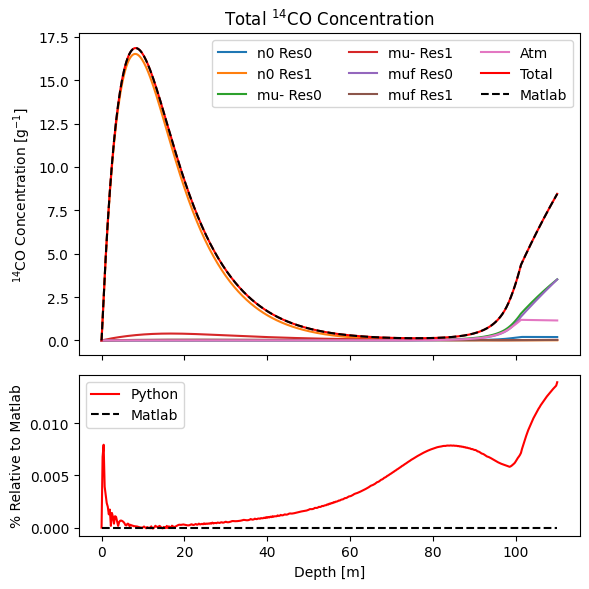

In [83]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

n = ['n0', 'mu-', 'muf']
for i in range(len(P0_tuning)):
    for j in range(len(Res)):
        axes[0].plot(Dome_C.z, P0_tuning[i] * (C14_grains + C14_cumuleak_closed + C14_closed_gas['C14_CO'])[:,i,j] * Res[j], label='{} Res{}'.format(n[i],j))
axes[0].plot(Dome_C.z, C14_closed_atm['C14_CO'], label='Atm')
axes[0].plot(Dome_C.z, P0_tuning @ (C14_grains + C14_cumuleak_closed + C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'], label='Total', c='r')
axes[0].plot(runMat['z'], runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1], label='Matlab', ls='--', c='k')
axes[0].legend(ncol=3)

axes[1].plot(Dome_C.z, (P0_tuning @ (C14_grains + C14_cumuleak_closed + C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])/(runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])*100-100, label='Python', c='r')
axes[1].plot(runMat['z'], (runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])/(runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])*100-100, label='Matlab', ls='--', c='k')
axes[1].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Total $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='% Relative to Matlab',
    xlabel='Depth [m]',
)

[Text(0, 0.5, '% Relative to Matlab'), Text(0.5, 0, 'Depth [m]')]

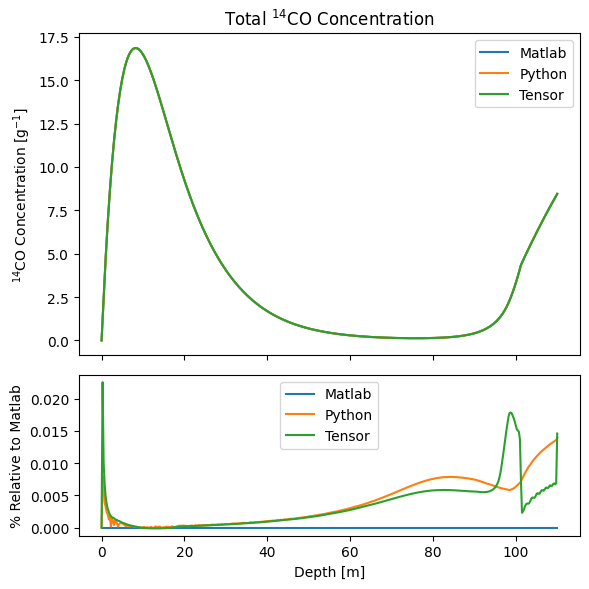

In [84]:
fig, axes = plt.subplots(2,1, figsize=(6,6), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

axes[0].plot(runMat['z'], runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1], label='Matlab')
axes[0].plot(Dome_C.z, P0_tuning @ (C14_grains + C14_cumuleak_closed + C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'], label='Python')
axes[0].plot(z, Res @ (A_profile @ P) + A_trap_atm @ gas_history, label='Tensor')
axes[0].legend()

axes[1].plot(runMat['z'], (runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])/(runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])*100-100, label='Matlab')
axes[1].plot(Dome_C.z, (P0_tuning @ (C14_grains + C14_cumuleak_closed + C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])/(runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])*100-100, label='Python')
axes[1].plot(z, (Res @ (A_profile @ P) + A_trap_atm @ gas_history)/(runMat['C14_grains'][:,-1,1] + runMat['C14_closed'][:,-1,1])*100-100, label='Tensor')
axes[1].legend()

axes[0].set(
    ylabel=r'$^{14}$CO Concentration [g$^{-1}$]',
    title=r'Total $^{14}$CO Concentration',
)

axes[1].set(
    ylabel='% Relative to Matlab',
    xlabel='Depth [m]',
)

In [ ]:
#c_pred = Res @ (A_total @ P)
#plt.plot(z, Res @ (A_profile @ P), ls='--', c='k')
#plt.errorbar(z_samp, c_pred, fmt='.', xerr=dz_samp/2, c='k')
#for i in range(3):
    #plt.errorbar(z_exp[i_samples[i]:i_samples[i+1]], CO_exp[i_samples[i]:i_samples[i+1]], yerr=dCO_exp[i_samples[i]:i_samples[i+1]], fmt='.')